In [1]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 7.2 MB/s eta 0:00:00


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abhishekbuddiga06/raabindata-nucleus-cytoplasm-ground-truths")

print("Path to dataset files:", path)


100%|██████████| 50.7M/50.7M [00:00<00:00, 177MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/abhishekbuddiga06/raabindata-nucleus-cytoplasm-ground-truths/versions/1


In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import skfuzzy as fuzz
from tqdm import tqdm
from sklearn.metrics import jaccard_score

In [4]:
DATA_PATH = "/root/.cache/kagglehub/datasets/abhishekbuddiga06/raabindata-nucleus-cytoplasm-ground-truths/versions/1"

print("Folders inside dataset:")
print(os.listdir(DATA_PATH))

Folders inside dataset:
['GrTh']


In [5]:
DATA_PATH = path   # use kagglehub path

print("Inside GrTh folder:")
print(os.listdir(os.path.join(DATA_PATH, "GrTh")))

Inside GrTh folder:
['Ground Truth', 'Original']


In [6]:
print("DATA_PATH:", DATA_PATH)
print("Inside GrTh:", os.listdir(os.path.join(DATA_PATH, "GrTh")))

print("\nInside Original:")
print(os.listdir(os.path.join(DATA_PATH, "GrTh", "Original")))

print("\nInside Ground Truth:")
print(os.listdir(os.path.join(DATA_PATH, "GrTh", "Ground Truth")))

DATA_PATH: /root/.cache/kagglehub/datasets/abhishekbuddiga06/raabindata-nucleus-cytoplasm-ground-truths/versions/1
Inside GrTh: ['Ground Truth', 'Original']

Inside Original:
['Monocyte', 'Basophil', 'Neutrophil', 'Lymphocyte', 'Eosinophil']

Inside Ground Truth:
['Monocyte', 'Basophil', 'Neutrophil', 'Lymphocyte', 'Eosinophil']


In [7]:
# Use kagglehub downloaded path
DATA_PATH = path

GRTH_PATH = os.path.join(DATA_PATH, "GrTh")

image_folder = os.path.join(GRTH_PATH, "Original")
mask_folder = os.path.join(GRTH_PATH, "Ground Truth")

print("Images:", len(os.listdir(image_folder)))
print("Masks:", len(os.listdir(mask_folder)))

Images: 5
Masks: 5


In [8]:
def load_image_mask(img_path, mask_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(mask_path, 0)
    mask = (mask > 127).astype(np.uint8)

    return img, mask


def preprocess_image(img):
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    return lab


def post_process(binary):
    kernel = np.ones((3,3), np.uint8)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
    return binary

In [9]:
def kmeans_segmentation(img):
    lab = preprocess_image(img)
    pixel_values = lab.reshape((-1, 3))
    pixel_values = np.float32(pixel_values)

    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    labels = kmeans.fit_predict(pixel_values)

    labels = labels.reshape(img.shape[:2])

    # Select cluster with darkest mean (usually nucleus)
    cluster_means = []
    for i in range(3):
        cluster_means.append(np.mean(lab[:,:,0][labels==i]))

    nucleus_cluster = np.argmin(cluster_means)

    binary = (labels == nucleus_cluster).astype(np.uint8)
    binary = post_process(binary)

    return binary

In [10]:
def fcm_segmentation(img):
    lab = preprocess_image(img)
    data = lab.reshape((-1, 3)).T

    cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
        data,
        c=3,
        m=2,
        error=0.005,
        maxiter=1000
    )

    cluster_membership = np.argmax(u, axis=0)
    cluster_membership = cluster_membership.reshape(img.shape[:2])

    cluster_means = []
    for i in range(3):
        cluster_means.append(np.mean(lab[:,:,0][cluster_membership==i]))

    nucleus_cluster = np.argmin(cluster_means)

    binary = (cluster_membership == nucleus_cluster).astype(np.uint8)
    binary = post_process(binary)

    return binary

In [11]:
def dice_score(y_true, y_pred):
    intersection = np.sum(y_true * y_pred)
    return (2. * intersection) / (np.sum(y_true) + np.sum(y_pred) + 1e-6)


def boundary_accuracy(y_true, y_pred):
    return jaccard_score(y_true.flatten(), y_pred.flatten())

In [16]:
import re

classes = os.listdir(os.path.join(DATA_PATH, "GrTh", "Original"))

kmeans_dice = []
fcm_dice = []
kmeans_jaccard = []
fcm_jaccard = []

for cls in classes:

    image_folder = os.path.join(DATA_PATH, "GrTh", "Original", cls)
    mask_folder  = os.path.join(DATA_PATH, "GrTh", "Ground Truth", cls)

    image_files = sorted([f for f in os.listdir(image_folder) if f.endswith(('.jpg', '.png'))])
    mask_files  = sorted([f for f in os.listdir(mask_folder) if f.endswith(('.jpg', '.png'))])

    for img_file in image_files:

        img_path = os.path.join(image_folder, img_file)
        mask_path = os.path.join(mask_folder, img_file)

        if not os.path.exists(mask_path):
            continue

        img = cv2.imread(img_path)
        mask = cv2.imread(mask_path, 0)

# Check first
        if img is None or mask is None:
            continue

# Resize for faster computation
img = cv2.resize(img, (256, 256))
mask = cv2.resize(mask, (256, 256))

# Convert and threshold
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
mask = (mask > 127).astype(np.uint8)

kmeans_pred = kmeans_segmentation(img)
fcm_pred = fcm_segmentation(img)

kmeans_dice.append(dice_score(mask, kmeans_pred))
fcm_dice.append(dice_score(mask, fcm_pred))

kmeans_jaccard.append(boundary_accuracy(mask, kmeans_pred))
fcm_jaccard.append(boundary_accuracy(mask, fcm_pred))

print("KMEANS Dice:", np.mean(kmeans_dice))
print("FCM Dice:", np.mean(fcm_dice))
print("KMEANS Jaccard:", np.mean(kmeans_jaccard))
print("FCM Jaccard:", np.mean(fcm_jaccard))

KMEANS Dice: 0.4313657002766883
FCM Dice: 0.42365572468330054
KMEANS Jaccard: 0.2749944333110666
FCM Jaccard: 0.26875837427422955


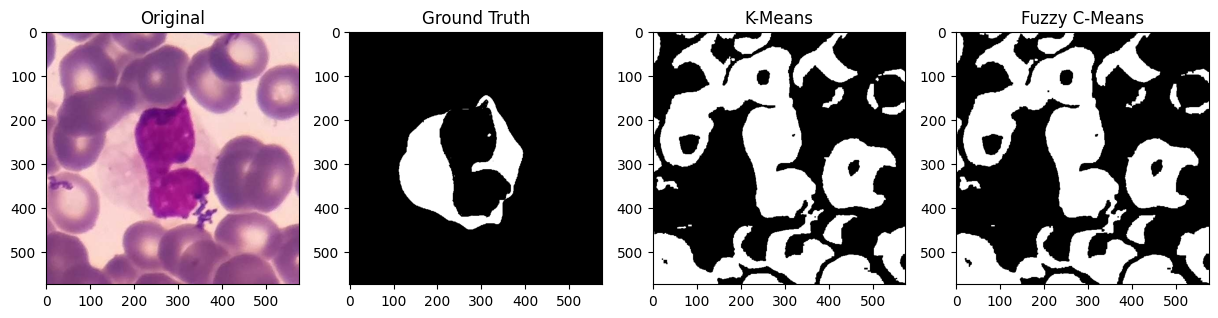

In [17]:
# Pick first class
cls = classes[0]

image_folder = os.path.join(DATA_PATH, "GrTh", "Original", cls)
mask_folder  = os.path.join(DATA_PATH, "GrTh", "Ground Truth", cls)

image_files = sorted(os.listdir(image_folder))

sample_img = image_files[0]

img_path = os.path.join(image_folder, sample_img)
mask_path = os.path.join(mask_folder, sample_img)

img = cv2.imread(img_path)
mask = cv2.imread(mask_path, 0)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
mask = (mask > 127).astype(np.uint8)

kmeans_pred = kmeans_segmentation(img)
fcm_pred = fcm_segmentation(img)

plt.figure(figsize=(15,5))

plt.subplot(1,4,1)
plt.imshow(img)
plt.title("Original")

plt.subplot(1,4,2)
plt.imshow(mask, cmap='gray')
plt.title("Ground Truth")

plt.subplot(1,4,3)
plt.imshow(kmeans_pred, cmap='gray')
plt.title("K-Means")

plt.subplot(1,4,4)
plt.imshow(fcm_pred, cmap='gray')
plt.title("Fuzzy C-Means")

plt.show()